## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bank-full data.csv to bank-full data.csv


Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

=== Numeric Feature Summary ===


,min,max,mean,std,skewness
0,,,,,
age,18,95,40.936,10.619,0.685
balance,-8019,102127,1362.272,3044.766,8.360
day,1,31,15.806,8.322,0.093
duration,0,4918,258.163,257.528,3.144
campaign,1,63,2.764,3.098,4.899
pdays,-1,871,40.198,100.129,2.616
previous,0,275,0.580,2.303,41.846


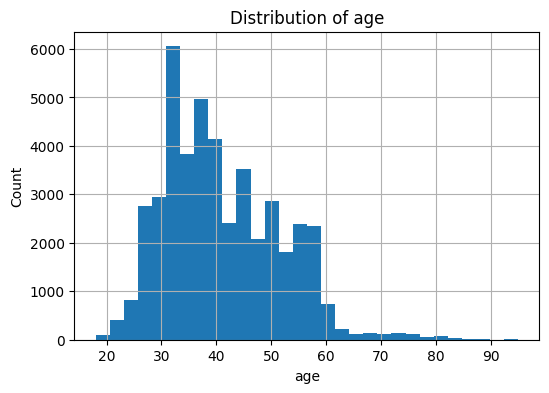

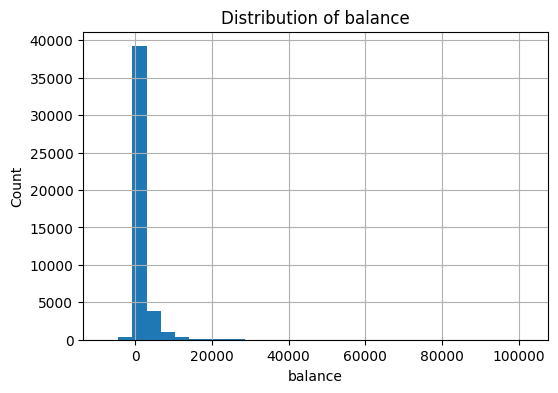

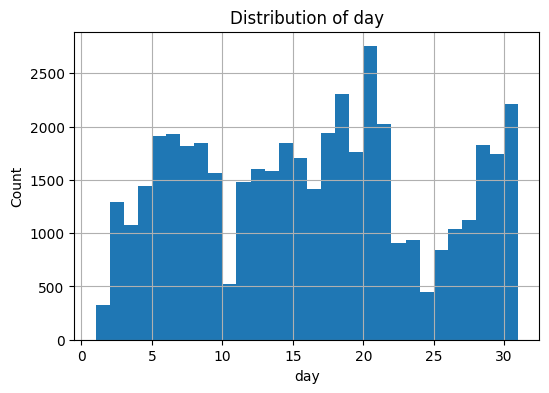

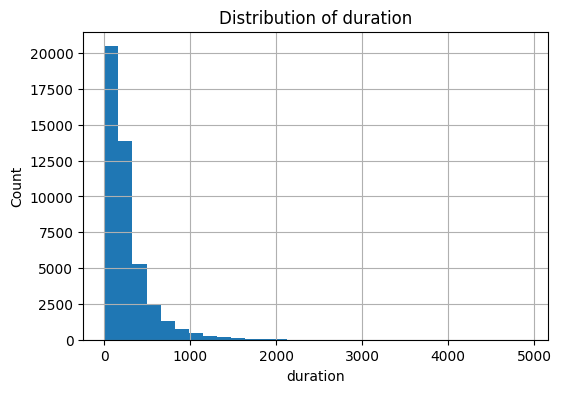

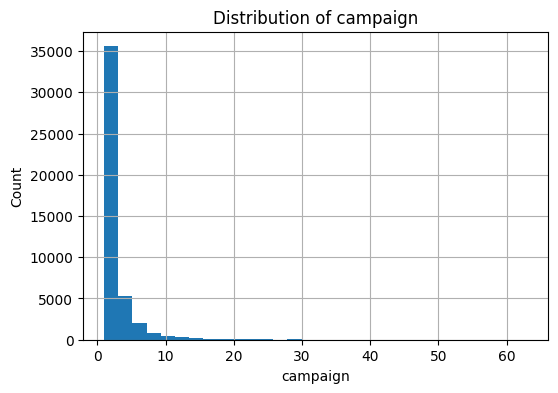

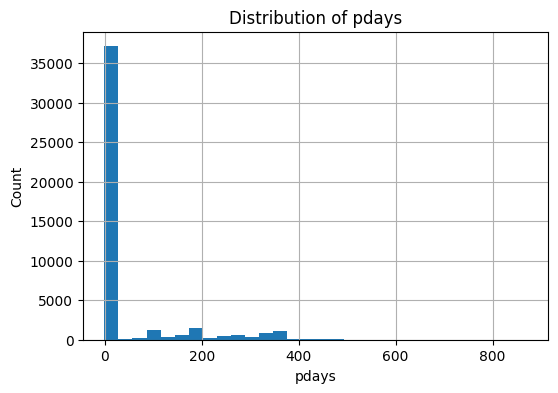

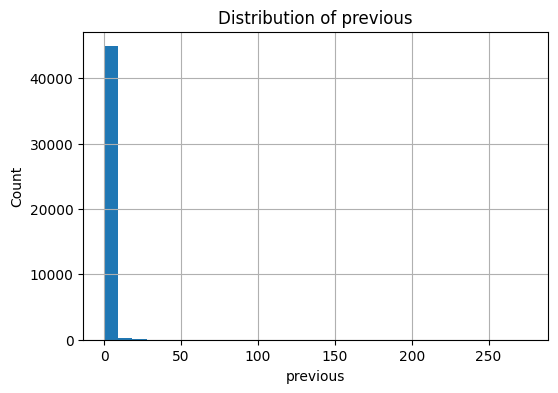


=== Categorical Value Counts (Top 20 each) ===

--- job ---


,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303



--- marital ---


,count
marital,
married,27214
single,12790
divorced,5207



--- education ---


...

,0
0,



=== 'unknown' Counts per Categorical Feature ===


,0
poutcome,36959
contact,13020
education,1857
job,288



Handling decision (recommended for clustering):
- Keep 'unknown' as its own category (do NOT drop rows).
- For numeric NaNs (if any), impute (median) or drop depending on count.

=== Numeric Correlation Matrix ===


,age,balance,day,duration,campaign,pdays,previous
0,,,,,,,
age,1.000,0.098,-0.009,-0.005,0.005,-0.024,0.001
balance,0.098,1.000,0.005,0.022,-0.015,0.003,0.017
day,-0.009,0.005,1.000,-0.030,0.162,-0.093,-0.052
duration,-0.005,0.022,-0.030,1.000,-0.085,-0.002,0.001
campaign,0.005,-0.015,0.162,-0.085,1.000,-0.089,-0.033
pdays,-0.024,0.003,-0.093,-0.002,-0.089,1.000,0.455
previous,0.001,0.017,-0.052,0.001,-0.033,0.455,1.000


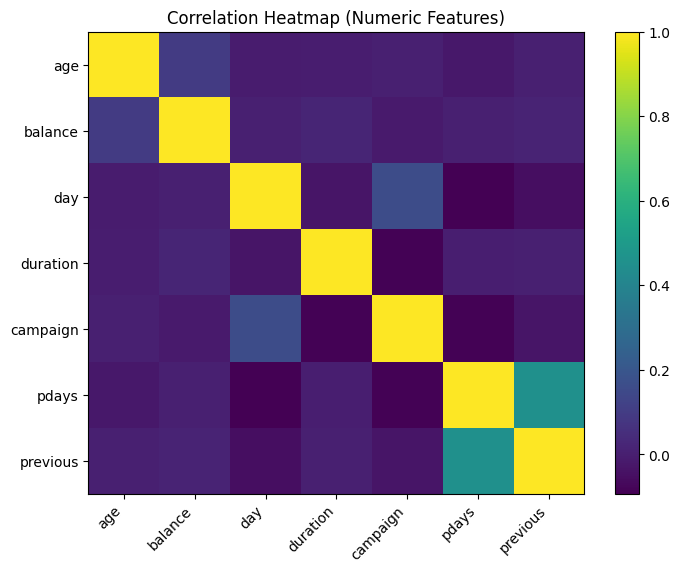


=== Outlier Report (IQR rule) ===


,feature,IQR_lower,IQR_upper,outliers_count,outliers_%
0,age,10.5,70.5,487,1.08
1,balance,-1962.0,3462.0,4729,10.46
2,day,-11.5,40.5,0,0.00
3,duration,-221.0,643.0,3235,7.16
4,campaign,-2.0,6.0,3064,6.78
5,pdays,-1.0,-1.0,8257,18.26
6,previous,0.0,0.0,8257,18.26


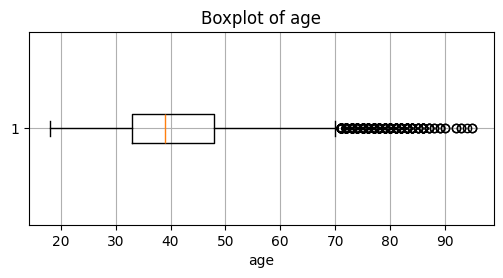

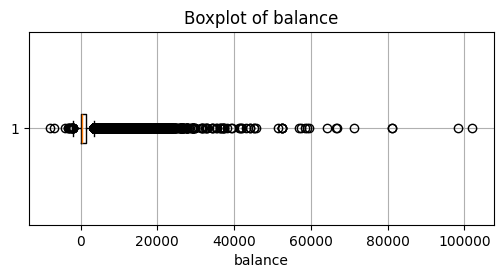

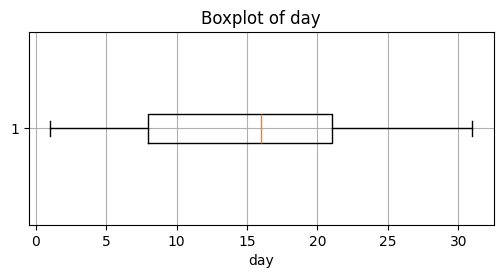

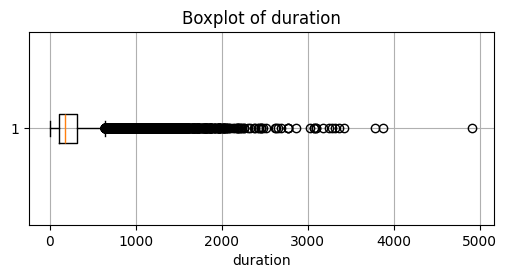

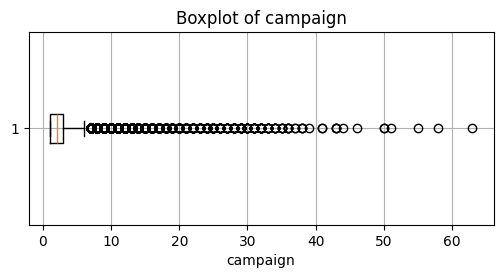

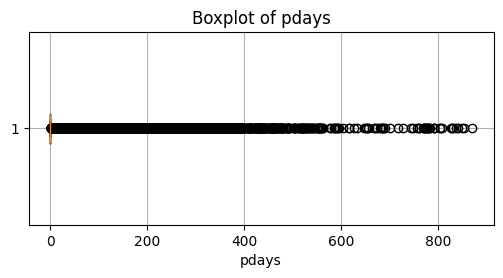

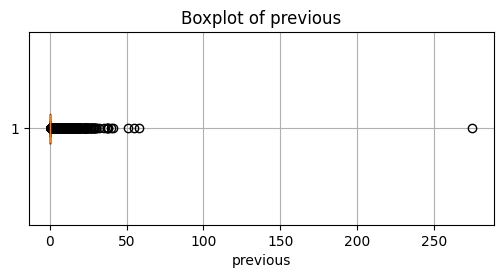

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SAFETY: do NOT modify df
# -----------------------------
df_eda = df.copy(deep=True)

# 1) Identify numeric vs categorical features
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
# In your dataset, most columns are strings. So we explicitly define numeric columns:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
categorical_cols = [c for c in df_eda.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Ensure numeric columns are numeric ONLY in df_eda (not df)
for c in numeric_cols:
    df_eda[c] = pd.to_numeric(df_eda[c], errors="coerce")

# -----------------------------
# 2) Numeric distributions (min, max, mean, std, skewness)
# -----------------------------
num_summary = pd.DataFrame({
    "min": df_eda[numeric_cols].min(),
    "max": df_eda[numeric_cols].max(),
    "mean": df_eda[numeric_cols].mean(),
    "std": df_eda[numeric_cols].std(),
    "skewness": df_eda[numeric_cols].skew()
}).round(3)

print("\n=== Numeric Feature Summary ===")
display(num_summary)

# Optional: histograms for numeric features
for c in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df_eda[c].dropna(), bins=30)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# -----------------------------
# 3) Counts of categories for categorical features
# -----------------------------
print("\n=== Categorical Value Counts (Top 20 each) ===")
for c in categorical_cols:
    print(f"\n--- {c} ---")
    display(df_eda[c].value_counts(dropna=False).head(20))

# -----------------------------
# 4) Missing / 'unknown' values
# -----------------------------
# True missing (NaN)
missing_counts = df_eda.isna().sum().sort_values(ascending=False)
print("\n=== Missing (NaN) Counts ===")
display(missing_counts[missing_counts > 0])

# 'unknown' counts (common in this dataset)
unknown_counts = {}
for c in categorical_cols:
    unknown_counts[c] = (df_eda[c].astype(str).str.lower() == "unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)
print("\n=== 'unknown' Counts per Categorical Feature ===")
display(unknown_counts[unknown_counts > 0])

print("\nHandling decision (recommended for clustering):")
print("- Keep 'unknown' as its own category (do NOT drop rows).")
print("- For numeric NaNs (if any), impute (median) or drop depending on count.")

# -----------------------------
# 5) Correlations between numeric features
# -----------------------------
corr = df_eda[numeric_cols].corr()

print("\n=== Numeric Correlation Matrix ===")
display(corr.round(3))

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap (Numeric Features)")
plt.colorbar()
plt.grid(False)
plt.show()

# -----------------------------
# 6) Outlier detection (IQR method) for numeric features
# -----------------------------
outlier_report = []

for c in numeric_cols:
    series = df_eda[c].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    outlier_pct = 100 * outliers / len(series)
    outlier_report.append([c, float(lower), float(upper), int(outliers), round(outlier_pct, 2)])

outlier_df = pd.DataFrame(outlier_report, columns=["feature","IQR_lower","IQR_upper","outliers_count","outliers_%"])
print("\n=== Outlier Report (IQR rule) ===")
display(outlier_df)

# Optional: Boxplots (quick outlier visual)
for c in numeric_cols:
    plt.figure(figsize=(6,2.5))
    plt.boxplot(df_eda[c].dropna(), vert=False)
    plt.title(f"Boxplot of {c}")
    plt.xlabel(c)
    plt.grid(True)
    plt.show()

### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose your file: bank-full data.csv (or bank-full.xlsx)

Saving bank-full data.csv to bank-full data.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Get the uploaded filename
file_path = list(uploaded.keys())[0]
print("Using file:", file_path)

# ---------- Load + clean (CSV that looks like: age;"job";...) ----------
raw = pd.read_csv(file_path, header=None)

df = raw[0].str.split(";", expand=True)
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

# Remove quotes
df.columns = df.columns.str.replace('"', '', regex=False)
df = df.applymap(lambda x: x.replace('"', '') if isinstance(x, str) else x)

print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- Drop target y ----------
y = df["y"].copy()
X_df = df.drop(columns=["y"]).copy()

# ---------- Convert numeric columns ----------
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
for col in numeric_cols:
    X_df[col] = pd.to_numeric(X_df[col], errors="coerce")

print("\nNaNs after numeric conversion:")
print(X_df[numeric_cols].isna().sum())

# ---------- Handle pdays = -1 ----------
X_df["previously_contacted"] = (X_df["pdays"] != -1).astype(int)
X_df["pdays_clean"] = X_df["pdays"].where(X_df["pdays"] != -1, 0)
X_df = X_df.drop(columns=["pdays"])

numeric_cols_prepared = [
    "age","balance","day","duration","campaign",
    "previous","pdays_clean","previously_contacted"
]

# ---------- One-hot encode categoricals ----------
categorical_cols = [c for c in X_df.columns if c not in numeric_cols_prepared]
X_encoded = pd.get_dummies(X_df, columns=categorical_cols, drop_first=False)

print("\nAfter one-hot encoding shape:", X_encoded.shape)

# ---------- Scale numeric features ----------
scaler = StandardScaler()
X_encoded[numeric_cols_prepared] = scaler.fit_transform(X_encoded[numeric_cols_prepared])

# ---------- Final checks ----------
print("\nFinal Checks:")
print("All numeric?",
      all(pd.api.types.is_numeric_dtype(X_encoded[c]) for c in X_encoded.columns))
print("Total missing values:", int(X_encoded.isna().sum().sum()))

X_prepared = X_encoded.values
print("Final prepared matrix shape:", X_prepared.shape)

Using file: bank-full data (1).csv


/tmp/ipython-input-2538161263.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.replace('"', '') if isinstance(x, str) else x)


Loaded shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

NaNs after numeric conversion:
0
age         0
balance     0
day         0
duration    0
campaign    0
pdays       0
previous    0
dtype: int64

After one-hot encoding shape: (45211, 52)

Final Checks:
All numeric? True
Total missing values: 0
Final prepared matrix shape: (45211, 52)


In [ ]:
print("Is 'y' still in dataset?", "y" in X_encoded.columns)

Is 'y' still in dataset? False


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [ ]:
import numpy as np
from sklearn.cluster import KMeans

# -----------------------------
# 1) Decide initial K
# -----------------------------
K = 3  # initial guess (we'll use Elbow later)
print("Using K =", K)

# -----------------------------
# 2) Fit K-Means model
# -----------------------------
kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_prepared)

# -----------------------------
# 3) Assign each point to a cluster
# -----------------------------
labels = kmeans.labels_

# Attach labels to original dataframe for analysis
df["cluster"] = labels

# Show results
unique, counts = np.unique(labels, return_counts=True)

print("\nK-Means Results:")
print("Inertia (SSD):", kmeans.inertia_)
print("Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} customers")

print("\nFirst 20 cluster assignments:")
print(labels[:20])

Using K = 3

K-Means Results:
Inertia (SSD): 429283.99337884074
Cluster sizes:
Cluster 0: 18868 customers
Cluster 1: 18096 customers
Cluster 2: 8247 customers

First 20 cluster assignments:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Explained variance (PC1+PC2): 0.30018376007981806


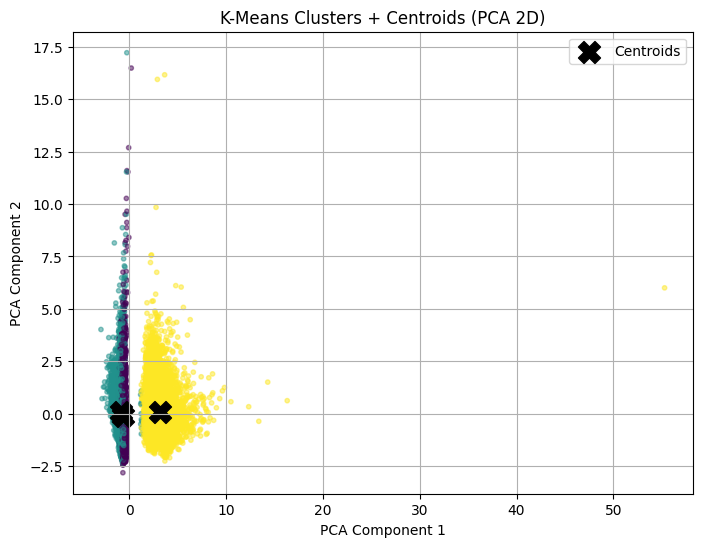

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1) Fit PCA and transform your data into 2D
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_prepared)

# 2) Transform KMeans centroids into the same PCA space
centroids_2d = pca.transform(kmeans.cluster_centers_)  # NOTE: cluster_centers_ not cluster_center_

print("Explained variance (PC1+PC2):", pca.explained_variance_ratio_.sum())

# 3) Plot points + centroids
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap="viridis", s=10, alpha=0.5)
plt.scatter(centroids_2d[:,0], centroids_2d[:,1], c="black", marker="X", s=250, label="Centroids")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters + Centroids (PCA 2D)")
plt.legend()
plt.grid(True)
plt.show()

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

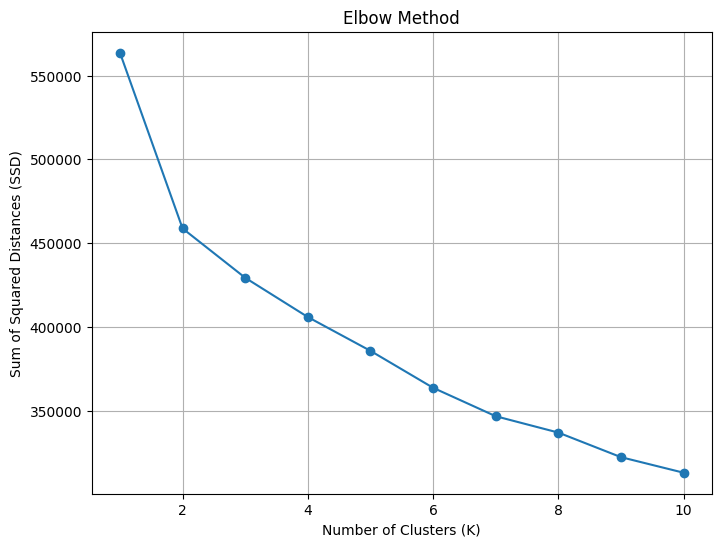

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

ssd = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_prepared)
    ssd.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

K=2, Silhouette Score=0.2937
K=3, Silhouette Score=0.1089
K=4, Silhouette Score=0.1115
K=5, Silhouette Score=0.1026
K=6, Silhouette Score=0.1221
K=7, Silhouette Score=0.1114
K=8, Silhouette Score=0.0997
K=9, Silhouette Score=0.1147
K=10, Silhouette Score=0.1083


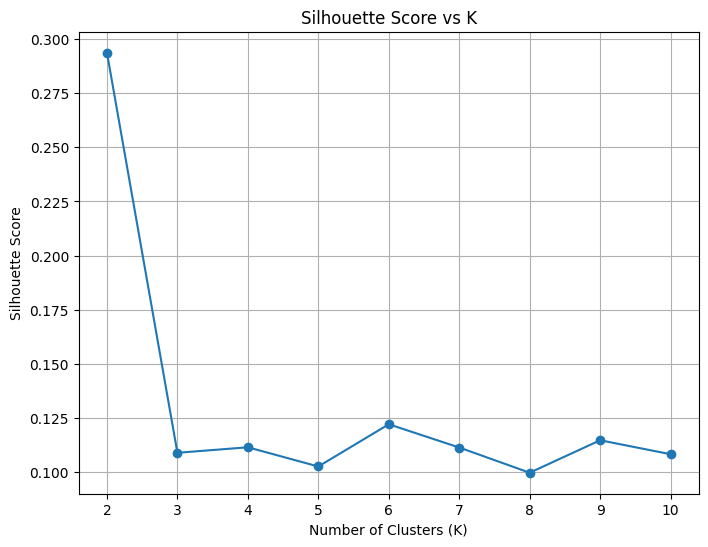

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):  # silhouette requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_prepared)
    score = silhouette_score(X_prepared, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8,6))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()